### Tests et explications de la méthode de la décomposition en tenseurs de rang r

In [ ]:
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

from skimage.metrics import structural_similarity as ssim
from tensorly.decomposition import parafac

random_state = 12345

In [39]:
image = plt.imread("../data/tensor_decomposition/bulbizzare.jpg")
image = tl.tensor(image, dtype='float64')

In [40]:
def to_image(tensor):
    """A convenience function to convert from a float dtype back to uint8"""
    im = tl.to_numpy(tensor)
    im -= im.min()
    im /= im.max()
    im *= 255
    return im.astype(np.uint8)

In [55]:
def compute_error(ref, other):
    return ssim(ref, other, channel_axis=2, data_range=other.max() - other.min())

In [59]:
def multi_ranks_cp(image_in):
    ranks=[1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
    fig, axs = plt.subplots(4, 4, figsize=(15,17))
    fig.suptitle('Rank R decomposition using CP method')

    base_data_size = image_in.shape[0] * image_in.shape[1] * 3

    axs[0][0].imshow(image_in / 255.0)
    axs[0][0].set_title(f"Reference\nData size = {base_data_size}")
    
    for i, rank in enumerate(ranks):
        lin = (i+1) // 4
        col = (i+1) % 4

        # Perform the CP decomposition
        weights, factors = parafac(image_in, rank=rank, init='random', tol=10e-6)
        # Reconstruct the image from the factors
        cp_reconstruction = tl.cp_to_tensor((weights, factors))

        data_size = (image_in.shape[0] + image_in.shape[1]) * 3 * rank
        compression = 1.0 - (data_size / base_data_size)
        error = compute_error(image_in, cp_reconstruction)

        axs[lin, col].imshow(to_image(cp_reconstruction))
        axs[lin, col].set_title(f'Rank = {rank}\n' +
                                f'Data size = {data_size} values\n' +
                                f'Compression = {compression:.2f}%\n' +
                                f'SSIM = {error:.2f}')

        print(f"Done for rank {rank}...")
    
    plt.tight_layout()
    plt.show()

Done for rank 1...
Done for rank 2...
Done for rank 5...
Done for rank 10...
Done for rank 15...
Done for rank 20...
Done for rank 25...
Done for rank 30...
Done for rank 40...
Done for rank 50...
Done for rank 60...
Done for rank 70...
Done for rank 80...
Done for rank 90...
Done for rank 100...


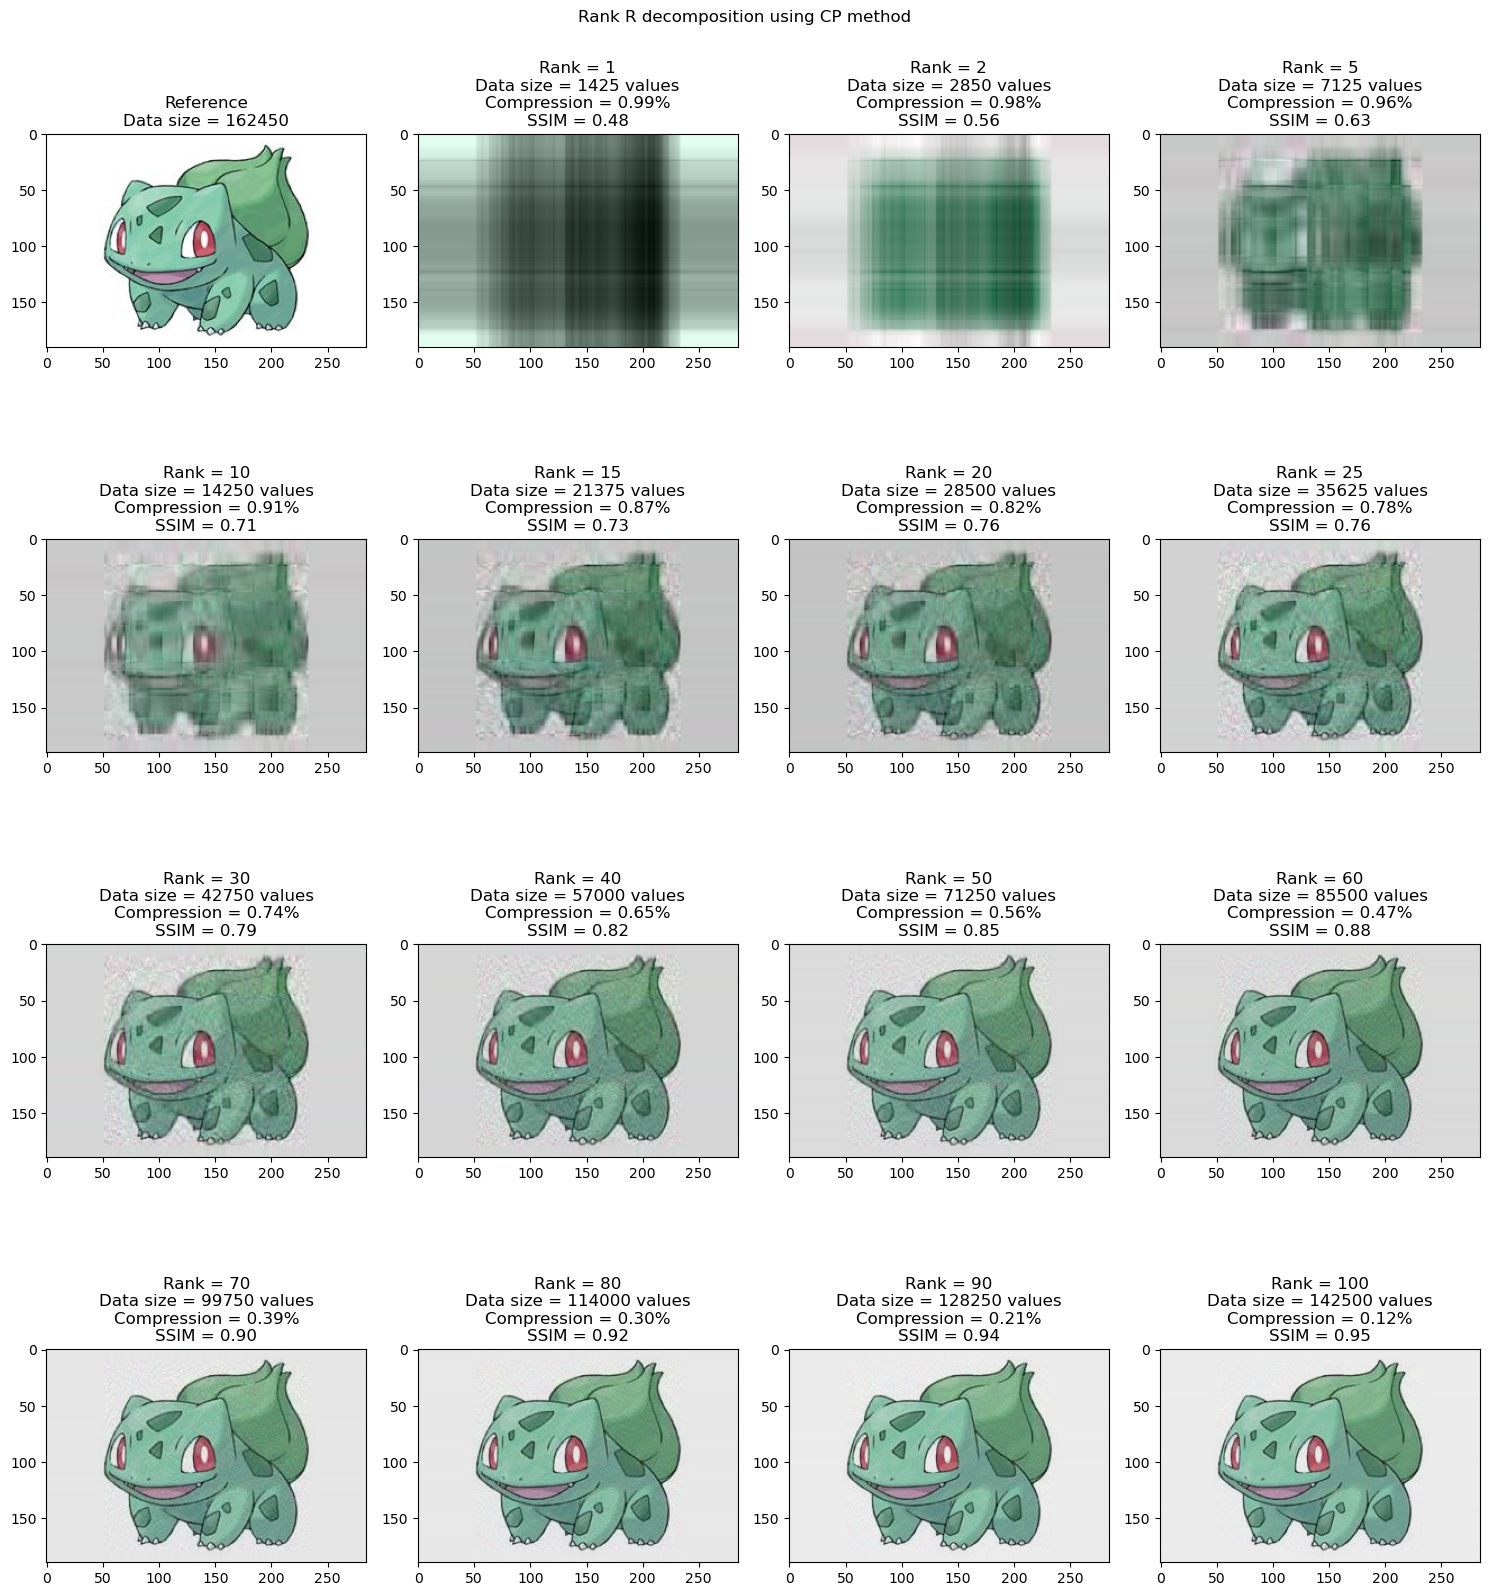

In [60]:
multi_ranks_cp(image)

In [77]:
def plot_rank_ssim(image_in):

    ranks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
    ssims = []
    sizes = []

    for r in ranks:
        weights, factors = parafac(image_in, rank=r, init='random', tol=10e-6)
        cp_reconstruction = tl.cp_to_tensor((weights, factors))

        ssims.append(compute_error(image_in, cp_reconstruction))
        sizes.append((image_in.shape[0] + image_in.shape[1]) * 3 * r)

        print(f"Rank {r} computed...")
    
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    ax1.plot(ranks, ssims)
    ax1.set_title("SSIM value in function of the rank decomposition")
    plt.show()


Rank 1 computed...
Rank 2 computed...
Rank 3 computed...
Rank 4 computed...
Rank 5 computed...
Rank 6 computed...
Rank 7 computed...
Rank 8 computed...
Rank 9 computed...
Rank 10 computed...
Rank 12 computed...
Rank 14 computed...
Rank 16 computed...
Rank 18 computed...
Rank 20 computed...
Rank 25 computed...
Rank 30 computed...
Rank 35 computed...
Rank 40 computed...
Rank 45 computed...
Rank 50 computed...
Rank 60 computed...
Rank 70 computed...
Rank 80 computed...
Rank 90 computed...
Rank 100 computed...


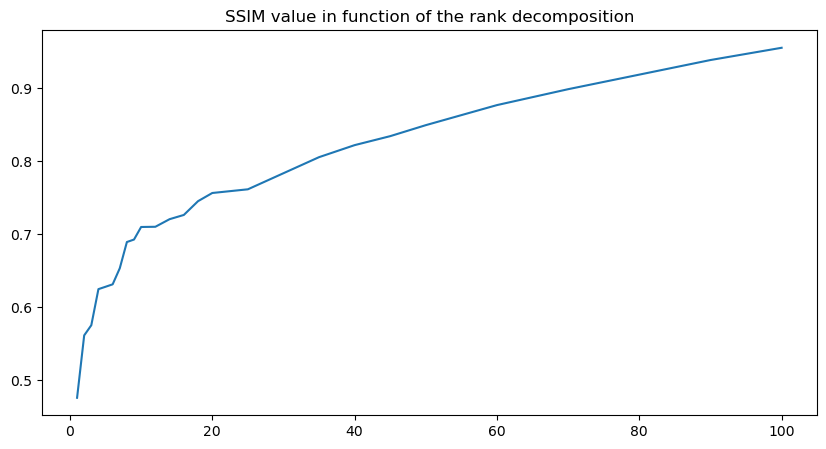

In [78]:
plot_rank_ssim(image)